In [1]:
!pip install gymnasium stable-baselines3 numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 31.7 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


In [5]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class NoisySensorEnv(gym.Env):
    def __init__(self):
        super(NoisySensorEnv, self).__init__()
        # The AI's Action: A calibration adjustment between -5.0 and 5.0
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        # The AI's Observation: The noisy, degraded sensor reading
        self.observation_space = spaces.Box(low=-100.0, high=100.0, shape=(1,), dtype=np.float32)

        self.true_value = 20.0 # e.g., Actual soil temperature is 20 degrees
        self.noise_level = 15.0 # The amount of "harsh condition" noise

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.current_noisy_reading = self.true_value + np.random.normal(0, self.noise_level)
        return np.array([self.current_noisy_reading], dtype=np.float32), {}

    def step(self, action):
        calibration_adjustment = action[0]
        calibrated_output = self.current_noisy_reading + calibration_adjustment

        # Reward the AI if the calibrated output is close to the true value
        error = abs(self.true_value - calibrated_output)
        reward = -error

        return np.array([self.current_noisy_reading], dtype=np.float32), reward, True, False, {}

In [6]:
from stable_baselines3 import PPO

# 1. Initialize our custom environment
env = NoisySensorEnv()

# 2. Create the PPO model
model = PPO("MlpPolicy", env, verbose=1)

# 3. Train the model
print("Starting training...")
model.learn(total_timesteps=10000)
print("Training complete!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting training...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | -11.6    |
| time/              |          |
|    fps             | 1635     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1            |
|    ep_rew_mean          | -11.4        |
| time/                   |              |
|    fps                  | 1123         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0055971653 |
|    clip_fraction        | 0.0438       |
|    clip_range           | 0

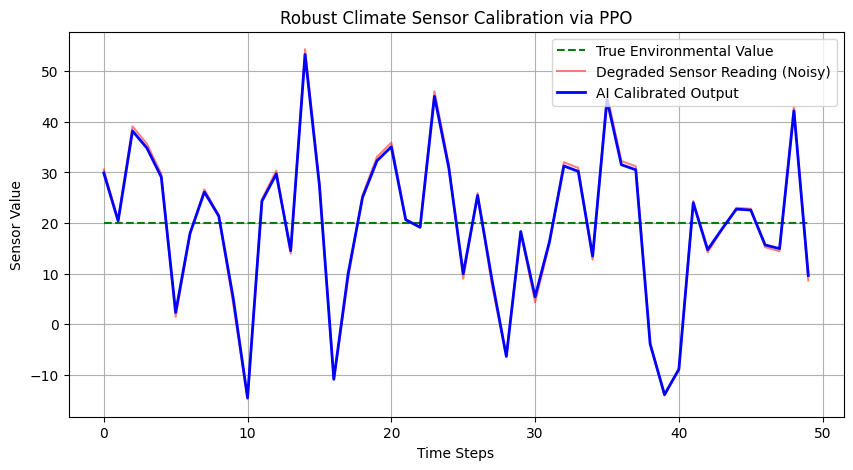

In [7]:
import matplotlib.pyplot as plt

# Simulate 50 different sensor readings over time
timesteps = 50
true_values = []
noisy_readings = []
calibrated_readings = []

for _ in range(timesteps):
    obs, info = env.reset()
    true_values.append(env.unwrapped.true_value)
    noisy_readings.append(obs[0])

    # Let the trained PPO model predict the fix
    action, _states = model.predict(obs, deterministic=True)
    calibrated_readings.append(obs[0] + action[0])

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(true_values, label="True Environmental Value", color="green", linestyle="--")
plt.plot(noisy_readings, label="Degraded Sensor Reading (Noisy)", color="red", alpha=0.5)
plt.plot(calibrated_readings, label="AI Calibrated Output", color="blue", linewidth=2)

plt.title("Robust Climate Sensor Calibration via PPO")
plt.xlabel("Time Steps")
plt.ylabel("Sensor Value")
plt.legend()
plt.grid(True)
plt.show()

Robust Climate Sensor calibration Under Degraded Conditions